In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [7]:
# read data 
data = pd.read_csv(filepath_or_buffer="capped_data.csv")
data.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes,is_satisfaction,is_loyal_customer,is_business_travel_type,is_Class
0,satisfied,Loyal Customer,65,Personal Travel,Eco,341,0,0,0,2,...,3,5,3,2,0,0.0,1,1,0,2
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,4,2,3,2,22,22.0,1,1,0,1
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,4,4,4,2,0,0.0,1,1,0,2
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,1,4,1,3,0,0.0,1,1,0,2
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,2,4,2,5,0,0.0,1,1,0,2


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129487 entries, 0 to 129486
Data columns (total 26 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129487 non-null  object 
 1   Customer Type                      129487 non-null  object 
 2   Age                                129487 non-null  int64  
 3   Type of Travel                     129487 non-null  object 
 4   Class                              129487 non-null  object 
 5   Flight Distance                    129487 non-null  int64  
 6   Seat comfort                       129487 non-null  int64  
 7   Departure/Arrival time convenient  129487 non-null  int64  
 8   Food and drink                     129487 non-null  int64  
 9   Gate location                      129487 non-null  int64  
 10  Inflight wifi service              129487 non-null  int64  
 11  Inflight entertainment             1294

In [9]:
data1 = data.drop(["satisfaction", "Customer Type", "Type of Travel", "Class"], axis=1)
data1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129487 entries, 0 to 129486
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Age                                129487 non-null  int64  
 1   Flight Distance                    129487 non-null  int64  
 2   Seat comfort                       129487 non-null  int64  
 3   Departure/Arrival time convenient  129487 non-null  int64  
 4   Food and drink                     129487 non-null  int64  
 5   Gate location                      129487 non-null  int64  
 6   Inflight wifi service              129487 non-null  int64  
 7   Inflight entertainment             129487 non-null  int64  
 8   Online support                     129487 non-null  int64  
 9   Ease of Online booking             129487 non-null  int64  
 10  On-board service                   129487 non-null  int64  
 11  Leg room service                   1294

In [10]:
data1.isnull().sum()

Age                                  0
Flight Distance                      0
Seat comfort                         0
Departure/Arrival time convenient    0
Food and drink                       0
Gate location                        0
Inflight wifi service                0
Inflight entertainment               0
Online support                       0
Ease of Online booking               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Cleanliness                          0
Online boarding                      0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
is_satisfaction                      0
is_loyal_customer                    0
is_business_travel_type              0
is_Class                             0
dtype: int64

✅ Model Accuracy: 0.9620
📊 Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.96     17582
           1       0.97      0.96      0.97     21265

    accuracy                           0.96     38847
   macro avg       0.96      0.96      0.96     38847
weighted avg       0.96      0.96      0.96     38847



<Axes: title={'center': 'Feature Importance'}>

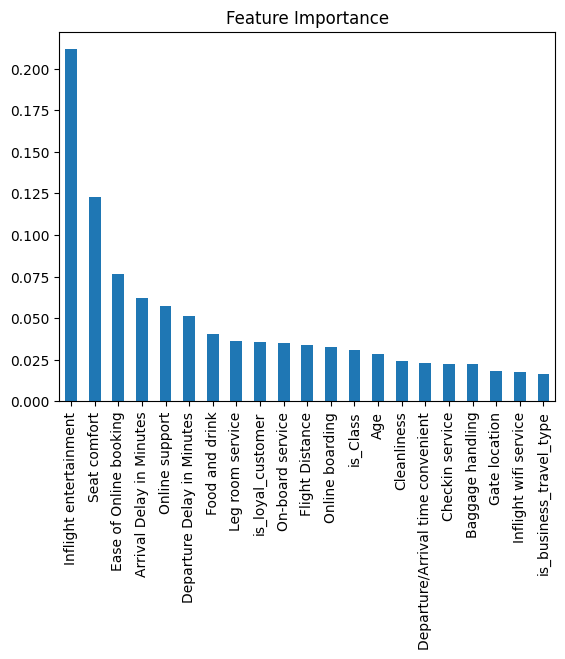

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# # Load both datasets
# capped_data = pd.read_csv("capped_data.csv")
# uncaped_data = pd.read_csv("uncaped_data.csv")

# Select which dataset to use (change this to switch between them)
df = data1  # Change to uncaped_data if needed

# # Encode categorical variables (if not already encoded)
# label_encoders = {}
# categorical_cols = ["Customer Type", "Type of Travel", "Class"]

# for col in categorical_cols:
#     le = LabelEncoder()
#     df[col] = le.fit_transform(df[col])
#     label_encoders[col] = le  # Store encoders for later use

# # Handle missing values (if any)
# df.fillna(df.median(), inplace=True)

# Define Features & Target
X = df.drop(columns=["is_satisfaction"])  # Features
y = df["is_satisfaction"]  # Target (classification)

# Split Data (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101, stratify=y)

# Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=101)
rf_model.fit(X_train, y_train)

# Make Predictions
y_pred = rf_model.predict(X_test)

# Evaluate Model
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {accuracy:.4f}")
print("📊 Classification Report:\n", classification_report(y_test, y_pred))

# Feature Importance (Optional)
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind="bar", title="Feature Importance")
